# Figure 3: Overview of training setup

## Package imports

In [71]:
 # General imports
import glob
import json
import random
import sys

# Data handling and visualization
import pandas as pd
import numpy as np
import evofr as ef
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import seaborn as sns

from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    get_filtered_growth_rates_df,
    filter_growth_rates
)

from antigentools.plot import (
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_cases, 
    plot_frequencies,
    get_analysis_window, # Move this to utils.py?
    print_window_stats, # Move this to utils.py?
)


# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics
build = "flu-simulated-150k-samples"
print(f"Analysis configuration for build: {build}:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")


Analysis configuration for build: flu-simulated-150k-samples:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  EPSILON (overestimation tolerance): 0.001


In [9]:
# Plotting configuration 
# Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

# Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

# Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

# Variant color map
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#5400ff'), (1, '#0074ff'), (2, '#ee00ff'), (3, '#00ff27'), (4, '#08ff00')]


In [4]:
fitness_path = f"../data/{build}/antigen-outputs/pruned_variant_fitness.csv"
truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")
fitness_df = pd.read_csv(fitness_path)

## Window setup

In [11]:
pivot_date="2053-04-01"
location="south"
model = "GARW"

growth_rates_df = get_filtered_growth_rates_df(
    build, model, location, pivot_date, spline_smoothing_factor=1.0, spline_order=3, min_sequence_count=MIN_SEQUENCE_COUNT, min_variant_frequency=MIN_VARIANT_FREQUENCY
)

Total cases: 30923.0
Total sequences: 3569.0
Variant counts: [1976. 1539.   54.]


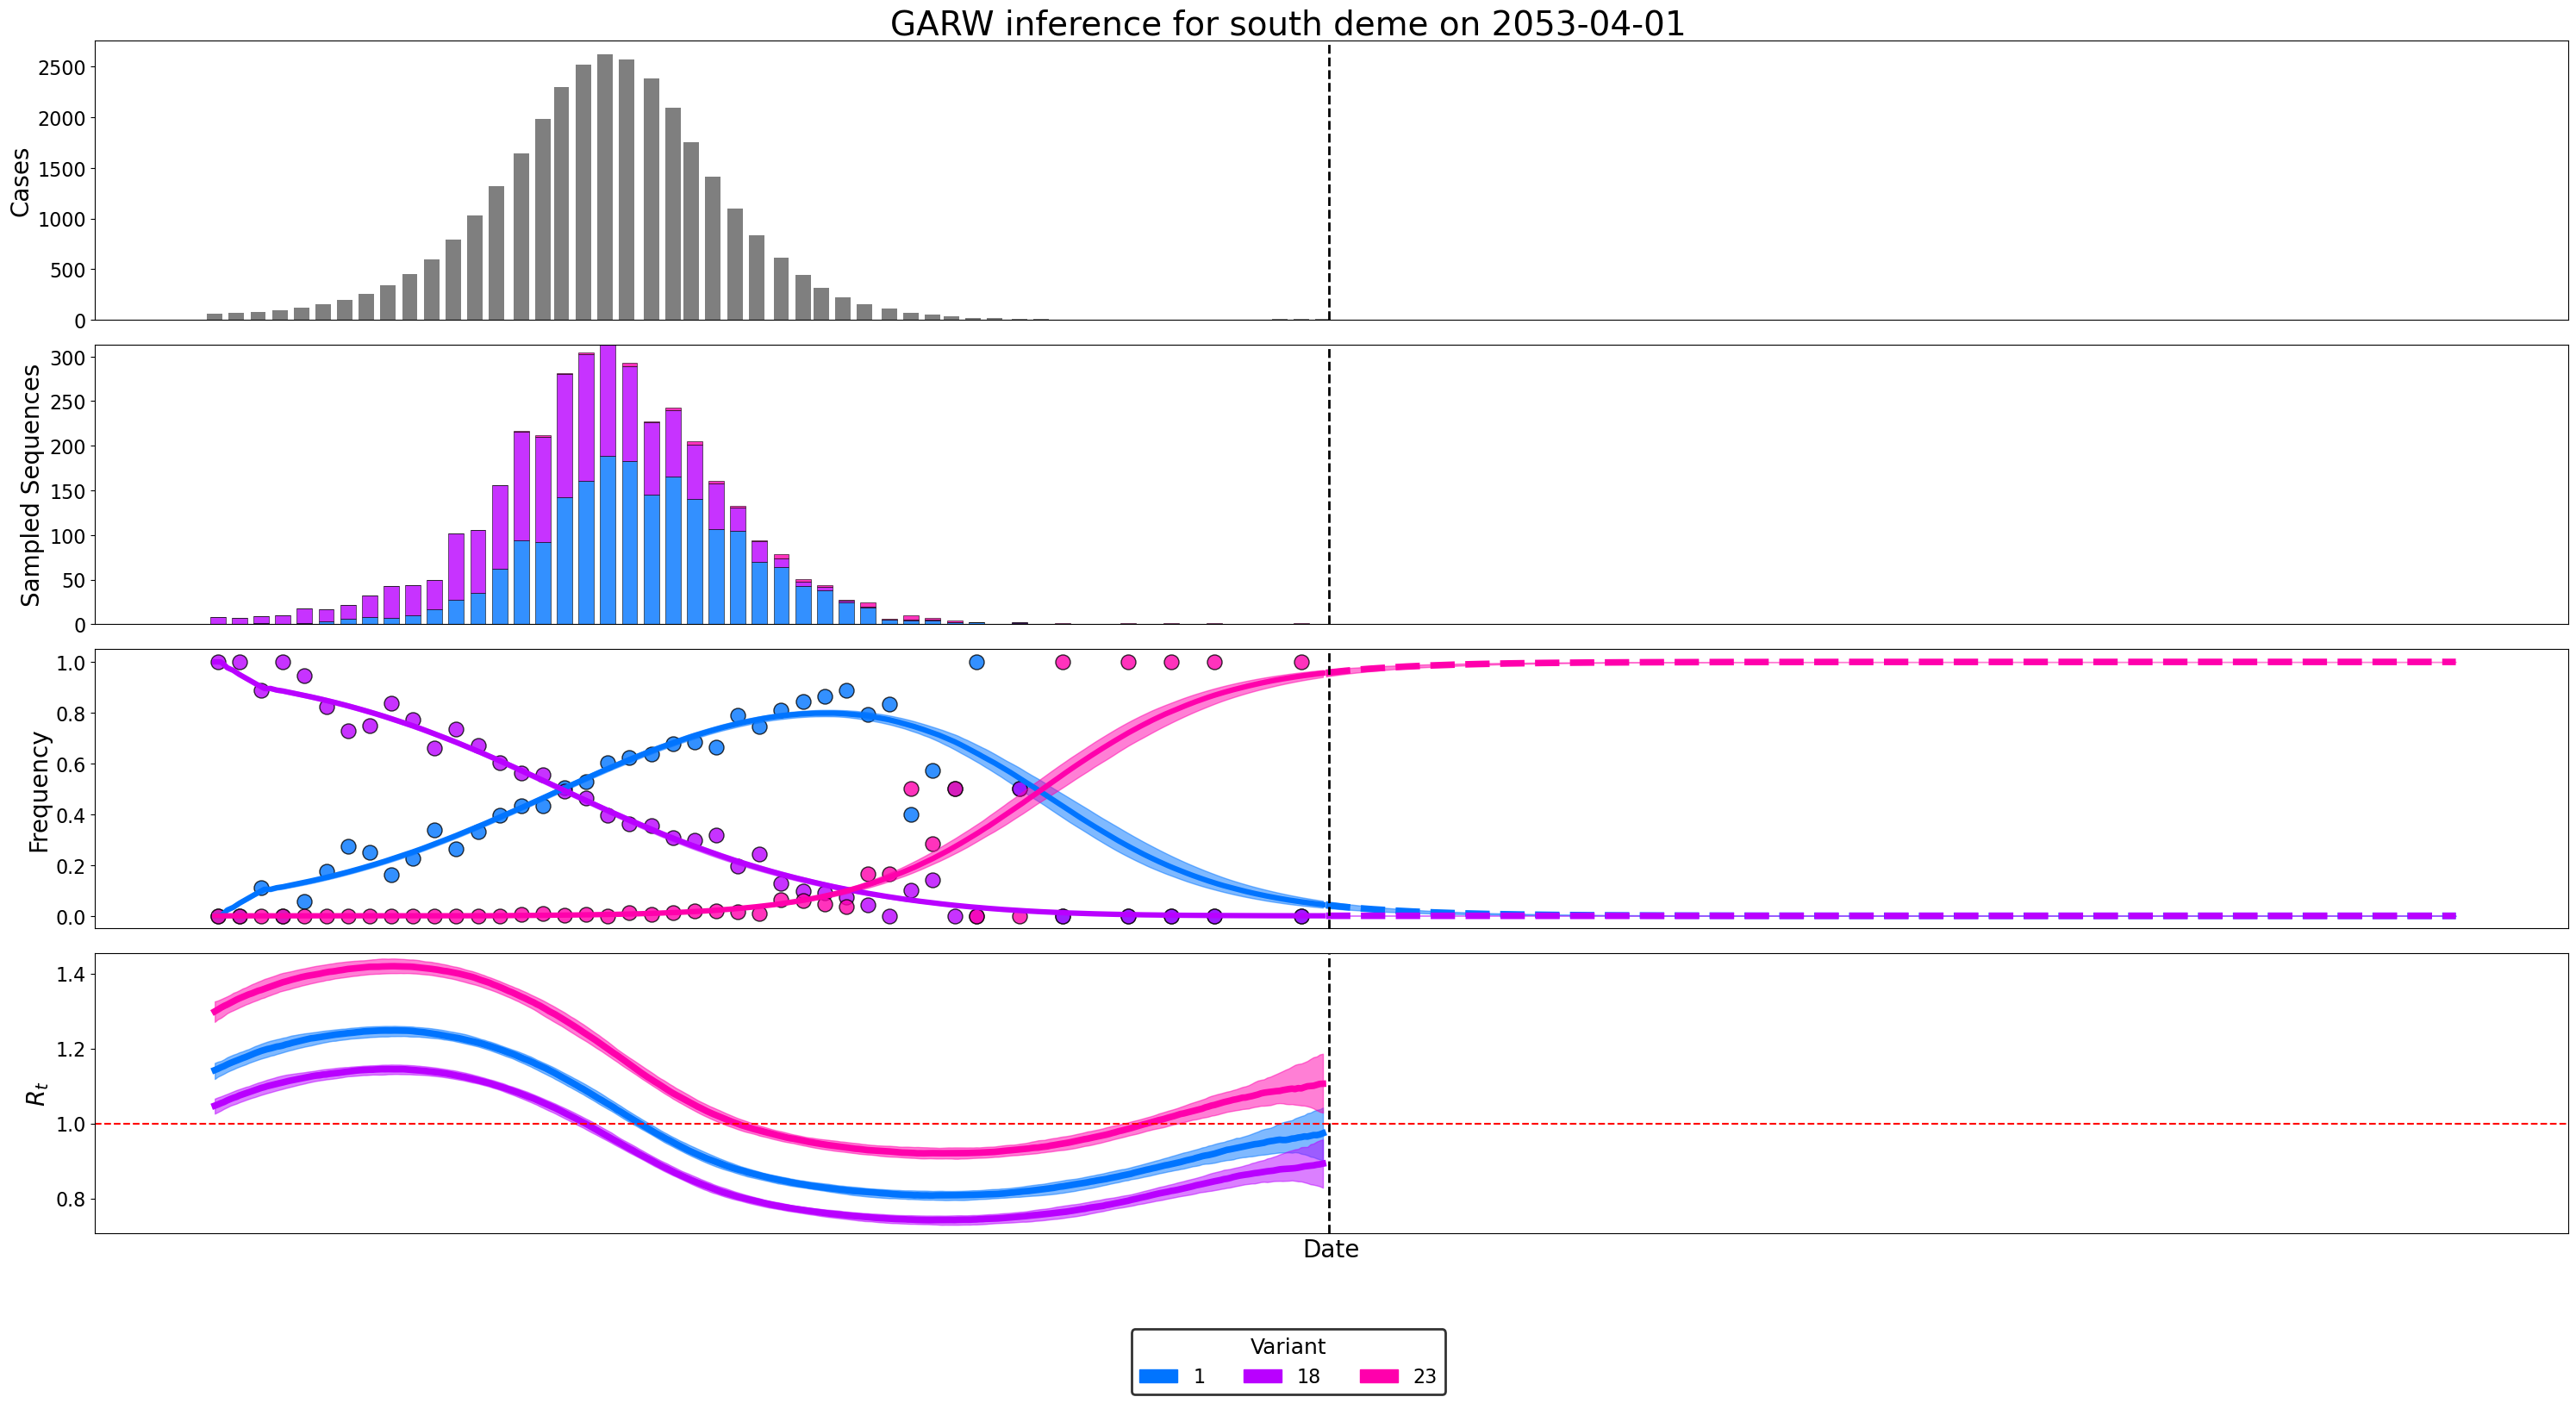

In [12]:
plot_analysis_window_with_variant_counts(
    pivot_date=pivot_date, 
    location=location, 
    model=model, 
    build=build, 
    color_map=color_map,
    **presentation_fonts
)

## Figure

In [115]:
def plot_schematic_panel(ax, evo_dict, location, pivot_idx=None, label_fontsize=18):
    """
    Plot a schematic panel showing retroactive nowcast vs forecast regions.
    This panel should not restrict the data range - just provide visual context.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        Axis to plot on
    evo_dict : dict
        Evolution data dictionary from evofr
    location : str
        Location to get date range from
    pivot_idx : list, optional
        List containing pivot index to mark analysis date
    label_fontsize : int
        Font size for text labels
    """
    # Get the consistent date range from evofr data but don't restrict other plots
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    
    # Don't set xlim - let it inherit from shared x-axis
    ax.set_ylim(0, 1)
    
    # Remove all axis elements except the frame
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel('')
    
    # Get pivot index
    if pivot_idx and len(pivot_idx) > 0:
        pivot_t = pivot_idx[0]
    else:
        # Get from the actual axis limits if available
        xlim = ax.get_xlim()
        pivot_t = (xlim[0] + xlim[1]) / 2  # Default to middle if no pivot provided
    
    # Get the actual x-axis limits (which will be set by other panels)
    xlim = ax.get_xlim()
    if xlim == (0.0, 1.0):  # Default limits, use evofr range
        x_min, x_max = 0, 2*len(dates_evofr) - 1
    else:
        x_min, x_max = xlim
    
    # Add background shading for the two regions
    # Retroactive nowcast region (left of pivot)
    ax.axvspan(x_min, pivot_t, alpha=0.2, color='lightblue', zorder=1)
    
    # Forecast region (right of pivot)  
    ax.axvspan(pivot_t, x_max, alpha=0.2, color='lightcoral', zorder=1)
    
    # Add the pivot line
    ax.axvline(x=pivot_t, color='black', linestyle='--', lw=3.0, zorder=3)
    
    # Add text labels
    # Retroactive nowcast label (middle of left region)
    nowcast_x = x_min + (pivot_t - x_min) / 2  # Middle of left region
    ax.text(nowcast_x, 0.5, 'Retroactive Nowcast', 
            ha='center', va='center', fontsize=label_fontsize, 
            fontweight='bold', zorder=4)
    
    # Forecast label (middle of right region, positioned further from pivot line)
    forecast_x = pivot_t + (x_max - pivot_t) / 2  # Middle of right region
    ax.text(forecast_x, 0.5, 'Forecast', 
            ha='center', va='center', fontsize=label_fontsize,
            fontweight='bold', zorder=4)
    
    # Add analysis date label at the pivot line
    ax.text(pivot_t, 0.85, 'Analysis Date', 
            ha='center', va='center', fontsize=label_fontsize-2,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            zorder=5)
    
    # Remove spines except bottom to maintain alignment with other panels
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

In [116]:
def plot_variant_incidence(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=14):
    """
    Plot variant incidence calculated from growth rates data.
    Uses consistent date mapping from evofr data.
    """
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No incidence data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Variant Incidence', fontsize=label_fontsize)
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot incidence for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty or 'variant_incidence_smoothed' not in variant_data.columns:
            continue
        
        # Convert week_start to normalized datetime
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Map week_start dates to t values using the evofr date mapping
        t_values = []
        incidence_values = []
        for idx, row in variant_data.iterrows():
            week_date = row['week_start_norm']
            # Find the closest date in our evofr date mapping
            if week_date in date_to_t:
                t_values.append(date_to_t[week_date])
                incidence_values.append(row['variant_incidence_smoothed'])
            else:
                # Find closest date if exact match not found
                date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                if date_diffs:
                    min_diff, closest_date = min(date_diffs)
                    if min_diff <= 7:  # Only include if within a week
                        t_values.append(date_to_t[closest_date])
                        incidence_values.append(row['variant_incidence_smoothed'])
        
        if not t_values:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Plot as line
        ax.plot(t_values, incidence_values, 
               color=variant_color, linewidth=5.5, label=f'Variant {variant}')
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=2.0)
    
    # Set labels and formatting
    ax.set_ylabel('Variant Incidence', fontsize=label_fontsize)

In [117]:
def plot_r_data_vs_r_model(ax, growth_rates_df, location, color_map, evo_dict, pivot_idx=None, label_fontsize=14):
    """
    Plot r_data (observed) vs r_model (inferred) growth rates with filtering similar to plot_growth_rate_dynamics.
    Similar to frequency plots: r_data as scatter points, r_model as lines.
    Uses consistent date mapping from evofr data and applies same filtering rules as plot_growth_rate_dynamics.
    """
    
    
    # Filter for the specific location
    location_data = growth_rates_df[growth_rates_df['country'] == location].copy()
    
    if location_data.empty:
        ax.text(0.5, 0.5, f'No growth rate data for {location}', 
                transform=ax.transAxes, ha='center', va='center', fontsize=label_fontsize)
        ax.set_ylabel('Growth Rate', fontsize=label_fontsize)
        return
    
    # Get the consistent date mapping from evofr data
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    date_to_t = {date: i for i, date in enumerate(dates_evofr)}
    
    # Get unique variants
    variants = sorted(location_data['variant'].unique())
    
    # Plot growth rates for each variant
    for variant in variants:
        variant_data = location_data[location_data['variant'] == variant].copy()
        
        if variant_data.empty:
            continue
            
        # Get color for this variant
        variant_color = color_map.get(variant, 'gray')
        
        # Convert week_start to normalized datetime and add to variant data
        variant_data['week_start_norm'] = pd.to_datetime(variant_data['week_start']).dt.normalize()
        
        # Apply the same filtering logic as plot_growth_rate_dynamics
        # First, basic NaN filtering for growth_rate_r_data
        valid_r_data = variant_data[~variant_data['growth_rate_r_data'].isna()].copy()
        
        # Apply advanced segment filtering if MIN_SEGMENT_LENGTH is specified
        if MIN_SEGMENT_LENGTH is not None:
            # Create a temporary DataFrame for this variant to apply filtering
            temp_df = variant_data.copy()
            temp_df['country'] = location  # Ensure location column exists for filtering
            temp_df['variant'] = variant   # Ensure variant column exists for filtering  
            temp_df['date'] = temp_df['week_start_norm']  # Use week_start as date for filtering
            
            filtered_variant_data = filter_growth_rates(
                temp_df, 
                r_data_col='growth_rate_r_data', 
                connect_gaps=CONNECT_GAPS, 
                min_segment_length=MIN_SEGMENT_LENGTH
            )
            valid_r_data = filtered_variant_data[~filtered_variant_data['growth_rate_r_data'].isna()].copy()
        
        # For median_r, use the same filtered data for consistency (same logic as plot_growth_rate_dynamics)
        if len(valid_r_data) > 0 and not valid_r_data['median_r'].isna().all():
            valid_model_data = valid_r_data[~valid_r_data['median_r'].isna()].copy()
        else:
            valid_model_data = pd.DataFrame()
        
        # Map week_start dates to t values for growth_rate_r_data
        if not valid_r_data.empty:
            t_values_r_data = []
            r_data_values = []
            
            for idx, row in valid_r_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date if exact match not found
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:  # Only include if within a week
                            t_value = date_to_t[closest_date]
                
                if t_value is not None and pd.notna(row['growth_rate_r_data']):
                    t_values_r_data.append(t_value)
                    r_data_values.append(row['growth_rate_r_data'])
            
            # Plot growth_rate_r_data (observed) as scatter points
            if t_values_r_data:
                ax.scatter(t_values_r_data, r_data_values, 
                          color=variant_color, alpha=0.8, s=150, 
                          edgecolors='black', label=f'Variant {variant} (observed)')
        
        # Map week_start dates to t values for median_r using the same filtered data
        if not valid_model_data.empty:
            t_values_r_model = []
            r_model_values = []
            
            for idx, row in valid_model_data.iterrows():
                week_date = row['week_start_norm']
                t_value = None
                if week_date in date_to_t:
                    t_value = date_to_t[week_date]
                else:
                    # Find closest date if exact match not found
                    date_diffs = [(abs((date - week_date).days), date) for date in dates_evofr]
                    if date_diffs:
                        min_diff, closest_date = min(date_diffs)
                        if min_diff <= 7:  # Only include if within a week
                            t_value = date_to_t[closest_date]
                
                if t_value is not None and pd.notna(row['median_r']):
                    t_values_r_model.append(t_value)
                    r_model_values.append(row['median_r'])
            
            # Plot median_r (inferred) as lines
            if t_values_r_model:
                # Sort by t_value for proper line plotting
                sorted_data = sorted(zip(t_values_r_model, r_model_values))
                sorted_t, sorted_r = zip(*sorted_data) if sorted_data else ([], [])
                ax.plot(sorted_t, sorted_r, 
                       color=variant_color, linewidth=4.5, alpha=0.9)
    
    # Add vertical lines for pivot indices
    if pivot_idx:
        for idx in pivot_idx:
            ax.axvline(x=idx, color='black', linestyle='--', lw=2.0)
    
    # Set labels and formatting
    ax.set_ylabel('Growth Rate (r)', fontsize=label_fontsize)
    
    # Add horizontal line at y=0 for reference
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

In [118]:
# Modified version of plot_analysis_window_with_variant_counts that replaces Rt with variant incidence
# and fitness with r_data vs r_model comparison
def plot_window_dynamics_with_incidence(pivot_date: str, location: str, model: str, build: str, 
                                       growth_rates_df: pd.DataFrame, color_map: dict, 
                                       title_fontsize: int = 18, label_fontsize: int = 14, tick_labelsize: int = 12,
                                       legend_fontsize: int = 12, legend_title_fontsize: int = 14) -> None:
    """
    Plot analysis window for a given location and model with variant incidence and r_data vs r_model.
    
    This creates a five-panel plot including:
    0. Schematic panel (retroactive nowcast vs forecast)
    1. Case counts
    2. Variant frequencies  
    3. Variant incidence (calculated from growth_rates_df)
    4. r_data vs r_model comparison (observed vs inferred growth rates)
    
    Parameters:
    -----------
    pivot_date : str
        Pivot date for analysis window
    location : str
        Location of interest
    model : str
        Model name
    build : str
        Build name
    growth_rates_df : pd.DataFrame
        DataFrame containing growth rates data with r_data and r_model columns
    color_map : dict
        Dictionary mapping variant names to colors
    title_fontsize : int, optional
        Font size for the figure title. Defaults to 18.
    label_fontsize : int, optional  
        Font size for axis labels. Defaults to 14.
    tick_labelsize : int, optional
        Font size for tick labels. Defaults to 12.
    legend_fontsize : int, optional
        Font size for legend text. Defaults to 12.
    legend_title_fontsize : int, optional
        Font size for legend title. Defaults to 14.
        
    Returns:
    --------
    None
    """
    
    # Get analysis window data (without fitness)
    dummy_fitness_df = pd.DataFrame(columns=['date', 'location', 'variant', 'fitness', 'seasonal_fitness', 't'])
    evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(pivot_date, build, dummy_fitness_df)
    
    # Get t value for pivot date
    pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")['t'].values[0]
    
    # Create t-to-date mapping from evofr data for x-axis labels
    dates_evofr = pd.to_datetime(evo_dict[location].dates).normalize()
    t_to_date = {i: date for i, date in enumerate(dates_evofr)}
    
    # Setup figure and grid with shared x-axis (5 panels with schematic)
    fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(30, 18), sharex=True)
    
    # Add a title
    fig.suptitle(f"{model} dynamics for {location} deme on {pivot_date}", fontsize=title_fontsize)
    
    # Subset color map to only include variants present in the deme
    available_variants = evo_dict[location].var_names
    filtered_color_map = {k: v for k, v in color_map.items() if k in available_variants}
    
    # Sort color map by variant name
    filtered_color_map = {k: filtered_color_map[k] for k in sorted(filtered_color_map.keys())}
    
    # Timestamps for dates
    dates = ef.data.expand_dates(evo_dict[location].dates, T_forecast=0)
    
    # Plot schematic panel (NEW - at the top)
    plot_schematic_panel(axs[0], evo_dict, location, pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    
    # Plot case counts
    plot_observed_cases(axs[1], evo_dict, location, pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    
    # Plot frequencies
    plot_frequencies(axs[2], evo_dict, small_freqs_df, location, model, filtered_color_map, p=50, pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    
    # Plot variant incidence (NEW - replaces Rt panel) - Pass evo_dict for consistent date mapping
    plot_variant_incidence(axs[3], growth_rates_df, location, filtered_color_map, evo_dict, pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    
    # Plot r_data vs r_model comparison (NEW - replaces fitness panel) - Pass evo_dict for consistent date mapping
    plot_r_data_vs_r_model(axs[4], growth_rates_df, location, filtered_color_map, evo_dict, pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    
    # Adjust axis visibility and font sizes
    for ax in axs[:-1]:  # Hide x-axis labels on all but the last subplot
        ax.label_outer()
    
    # Set tick label font sizes for all axes
    for ax in axs:
        ax.tick_params(axis='both', which='major', labelsize=tick_labelsize)
    
    # Add x-axis label and date formatting to bottom panel only
    axs[-1].set_xlabel("Date", fontsize=label_fontsize)
    
    # Format x-axis of bottom panel with actual dates
    # Set ticks at regular intervals (e.g., every 30 t values)
    tick_interval = 30
    tick_positions = list(range(0, len(t_to_date), tick_interval))
    if tick_positions and tick_positions[-1] != len(t_to_date) - 1:
        tick_positions.append(len(t_to_date) - 1)  # Always include the last point
    
    # Convert t positions to date strings
    tick_labels = []
    for t_pos in tick_positions:
        if t_pos in t_to_date:
            date_str = pd.Timestamp(t_to_date[t_pos]).strftime('%Y-%m-%d')
            tick_labels.append(date_str)
        else:
            tick_labels.append('')
    
    axs[-1].set_xticks(tick_positions)
    axs[-1].set_xticklabels(tick_labels, rotation=45, ha='right')
    
    # Create a legend
    patches = [mpatches.Patch(color=c, label=l) for l, c in filtered_color_map.items()]
    legend = fig.legend(patches, list(filtered_color_map.keys()), ncol=10, bbox_to_anchor=(0.5, -0.10), 
                       loc="lower center", title="Variant", fontsize=legend_fontsize, title_fontsize=legend_title_fontsize)  
    legend.get_frame().set_linewidth(2.0)
    legend.get_frame().set_edgecolor("k")
    fig.tight_layout()
    
    plt.show()

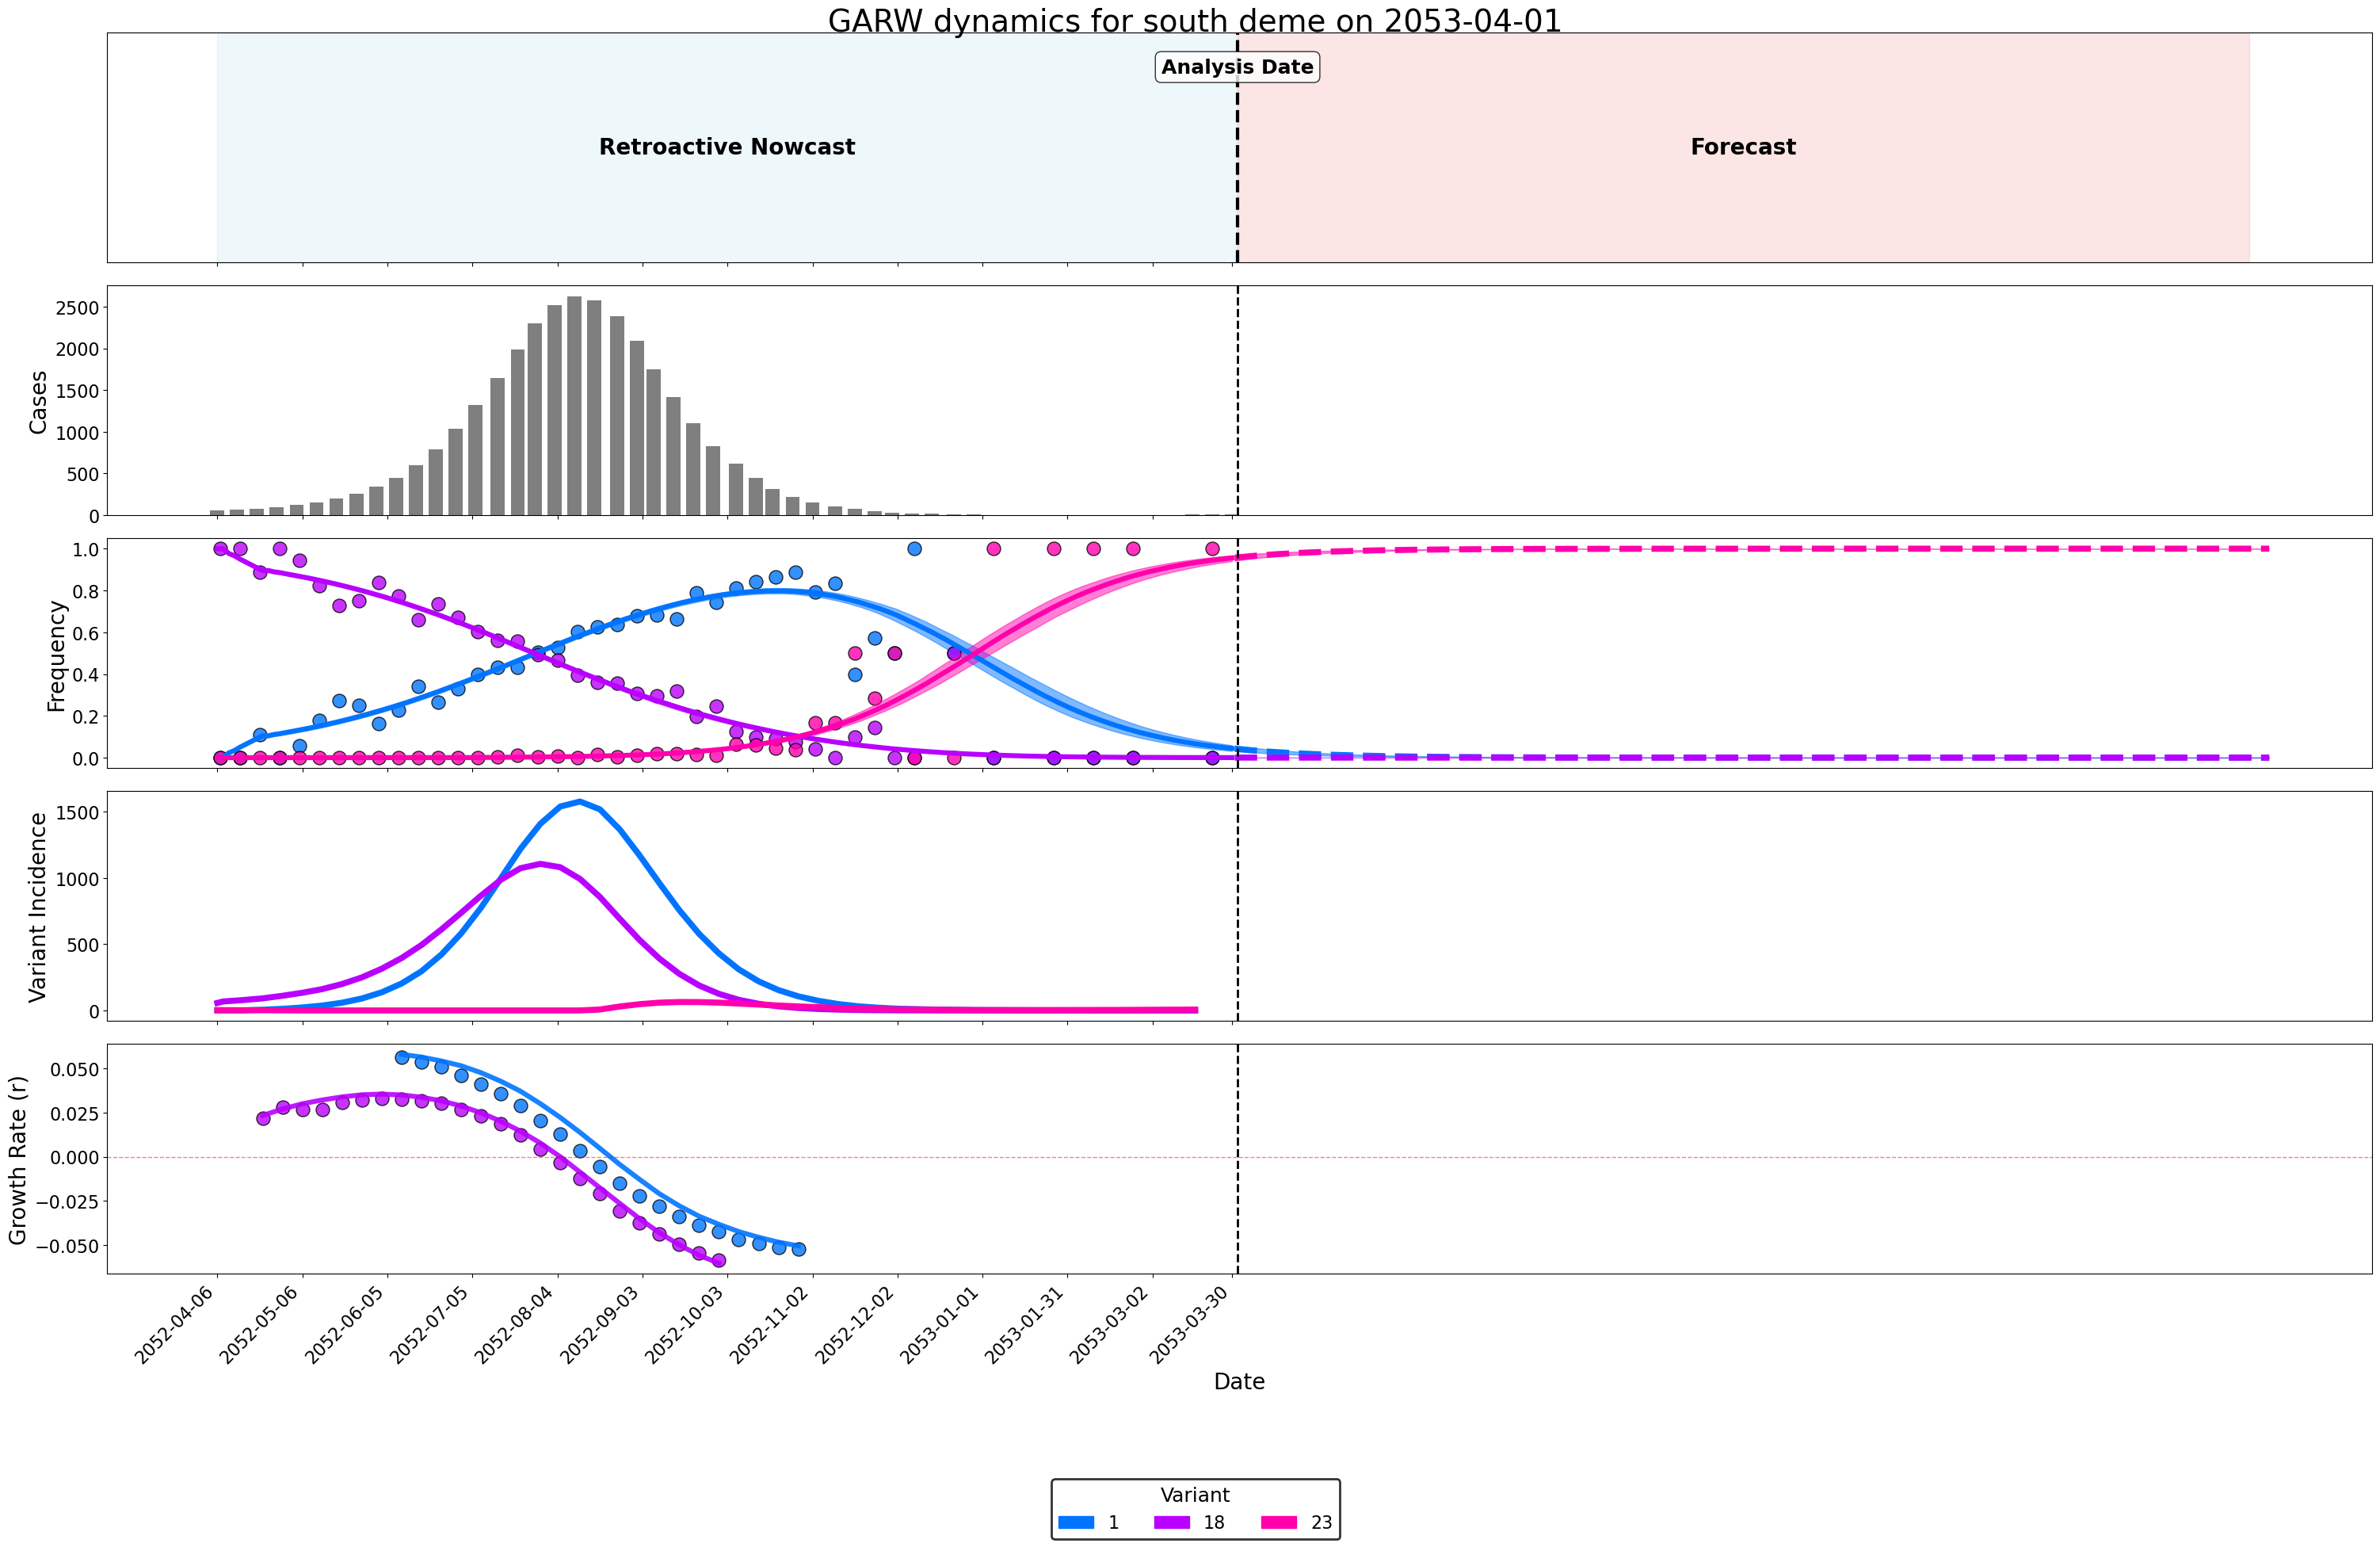

In [119]:
plot_window_dynamics_with_incidence(
      pivot_date=pivot_date,
      location=location,
      model=model,
      build=build,
      growth_rates_df=growth_rates_df,
      color_map=color_map,
      **presentation_fonts
  )